# Student Social Media Addiction - Data Analysis & Classification

In [1]:

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load dataset
df = pd.read_csv("../data/Students Social Media Addiction.csv")

# Encode categorical columns
df['Gender'] = df['Gender'].map({'Female': 0, 'Male': 1})
df['Affects_Academic_Performance'] = df['Affects_Academic_Performance'].map({'Yes': 1, 'No': 0})

# Drop missing values
df.dropna(inplace=True)

# Relabel Addicted_Score to start from 1
df['Addicted_Score'] = df['Addicted_Score'] - df['Addicted_Score'].min() + 1


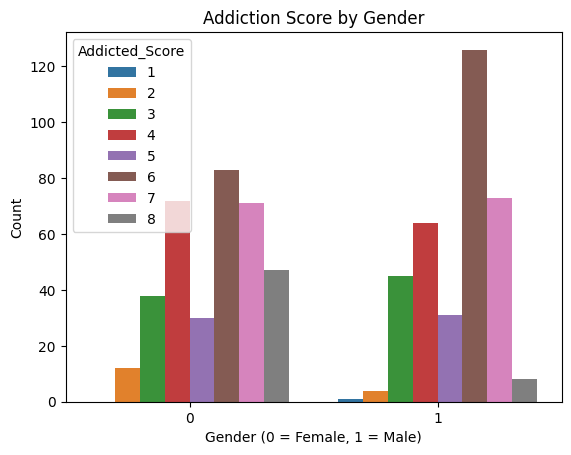

In [2]:

sns.countplot(data=df, x='Gender', hue='Addicted_Score')
plt.title("Addiction Score by Gender")
plt.xlabel("Gender (0 = Female, 1 = Male)")
plt.ylabel("Count")
plt.show()


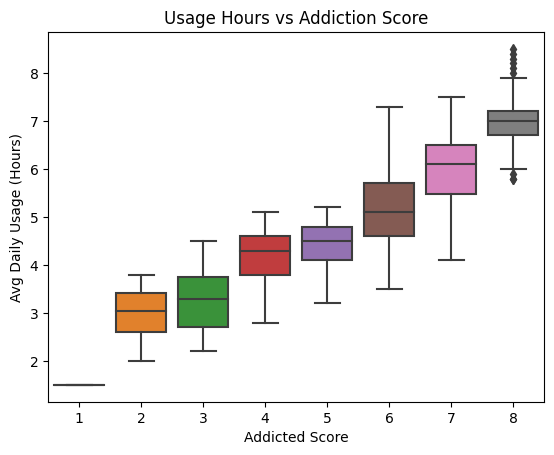

In [3]:

sns.boxplot(data=df, x='Addicted_Score', y='Avg_Daily_Usage_Hours')
plt.title("Usage Hours vs Addiction Score")
plt.xlabel("Addicted Score")
plt.ylabel("Avg Daily Usage (Hours)")
plt.show()


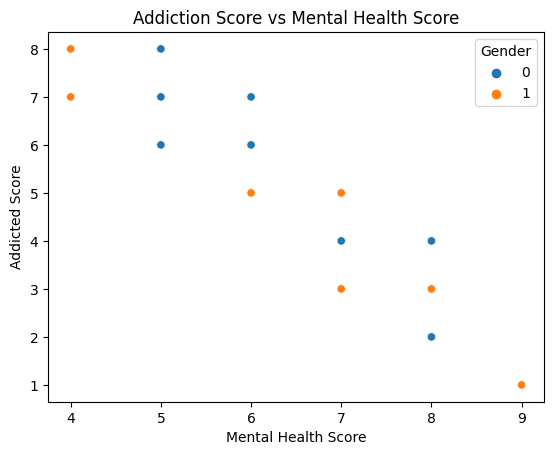

In [4]:

sns.scatterplot(data=df, x='Mental_Health_Score', y='Addicted_Score', hue='Gender')
plt.title("Addiction Score vs Mental Health Score")
plt.xlabel("Mental Health Score")
plt.ylabel("Addicted Score")
plt.show()


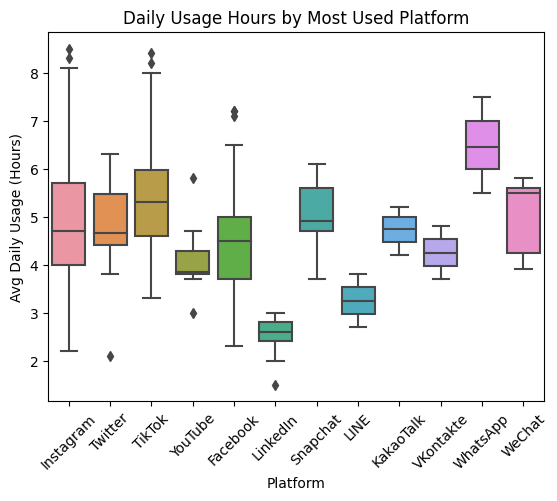

In [5]:

sns.boxplot(data=df, x='Most_Used_Platform', y='Avg_Daily_Usage_Hours')
plt.xticks(rotation=45)
plt.title("Daily Usage Hours by Most Used Platform")
plt.xlabel("Platform")
plt.ylabel("Avg Daily Usage (Hours)")
plt.show()


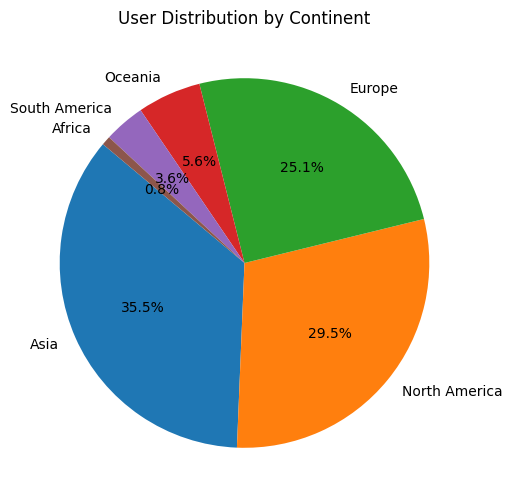

In [6]:

continent_map = {
    'USA': 'North America', 'Canada': 'North America',
    'India': 'Asia', 'Bangladesh': 'Asia', 'China': 'Asia',
    'UK': 'Europe', 'Germany': 'Europe', 'France': 'Europe',
    'Brazil': 'South America', 'Argentina': 'South America',
    'Australia': 'Oceania', 'Nigeria': 'Africa', 'South Africa': 'Africa'
}
df['Continent'] = df['Country'].map(continent_map)
continent_counts = df['Continent'].value_counts().dropna()

plt.figure(figsize=(6,6))
plt.pie(continent_counts, labels=continent_counts.index, autopct='%1.1f%%', startangle=140)
plt.title("User Distribution by Continent")
plt.show()


In [7]:

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import numpy as np

# Get dummies and scale
df = pd.get_dummies(df, columns=['Academic_Level', 'Country', 'Most_Used_Platform', 'Relationship_Status'], drop_first=True)
X = df.drop(columns=['Student_ID', 'Addicted_Score', 'Continent'], errors='ignore')
y = df['Addicted_Score'] - 1  # Now starts from 0

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Reshape for LSTM
X_train_lstm = X_train_scaled.reshape((X_train_scaled.shape[0], 1, X_train_scaled.shape[1]))
X_test_lstm = X_test_scaled.reshape((X_test_scaled.shape[0], 1, X_test_scaled.shape[1]))


In [8]:

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

model = Sequential()
model.add(LSTM(64, input_shape=(X_train_lstm.shape[1], X_train_lstm.shape[2]), return_sequences=False))
model.add(Dropout(0.2))
model.add(Dense(32, activation='relu'))
model.add(Dense(len(np.unique(y)), activation='softmax'))

model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

history = model.fit(X_train_lstm, y_train, epochs=30, batch_size=32, validation_data=(X_test_lstm, y_test))


Epoch 1/30
18/18 [==============================] - 4s 52ms/step - loss: 2.0513 - accuracy: 0.2394 - val_loss: 1.9647 - val_accuracy: 0.5674
Epoch 2/30
18/18 [==============================] - 0s 7ms/step - loss: 1.8915 - accuracy: 0.5975 - val_loss: 1.8121 - val_accuracy: 0.7021
Epoch 3/30
18/18 [==============================] - 0s 7ms/step - loss: 1.6979 - accuracy: 0.7039 - val_loss: 1.6048 - val_accuracy: 0.7305
Epoch 4/30
18/18 [==============================] - 0s 6ms/step - loss: 1.4504 - accuracy: 0.7323 - val_loss: 1.3321 - val_accuracy: 0.7589
Epoch 5/30
18/18 [==============================] - 0s 7ms/step - loss: 1.1707 - accuracy: 0.7606 - val_loss: 1.0506 - val_accuracy: 0.8085
Epoch 6/30
18/18 [==============================] - 0s 7ms/step - loss: 0.9112 - accuracy: 0.8050 - val_loss: 0.8254 - val_accuracy: 0.8369
Epoch 7/30
18/18 [==============================] - 0s 6ms/step - loss: 0.7104 - accuracy: 0.8617 - val_loss: 0.6656 - val_accuracy: 0.8369
Epoch 8/30
18/18 [=

5/5 [==============================] - 0s 0s/step - loss: 0.3981 - accuracy: 0.9078
Test Accuracy: 0.9078


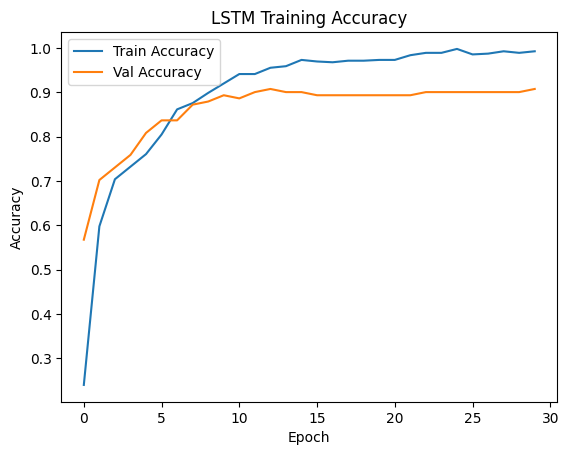

In [9]:

loss, accuracy = model.evaluate(X_test_lstm, y_test)
print(f"Test Accuracy: {accuracy:.4f}")

# Plot history
import matplotlib.pyplot as plt
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title("LSTM Training Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()


5/5 [==============================] - 1s 0s/step
Classification Report:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00         1
           1       1.00      1.00      1.00         2
           2       0.93      0.93      0.93        15
           3       0.97      1.00      0.99        35
           4       0.89      0.89      0.89         9
           5       0.97      0.88      0.92        41
           6       0.85      0.82      0.84        28
           7       0.67      1.00      0.80        10

    accuracy                           0.91       141
   macro avg       0.79      0.82      0.80       141
weighted avg       0.91      0.91      0.91       141



C:\Users\Asus\anaconda3\envs\MS\lib\site-packages\sklearn\metrics\_classification.py:1318: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
C:\Users\Asus\anaconda3\envs\MS\lib\site-packages\sklearn\metrics\_classification.py:1318: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
C:\Users\Asus\anaconda3\envs\MS\lib\site-packages\sklearn\metrics\_classification.py:1318: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


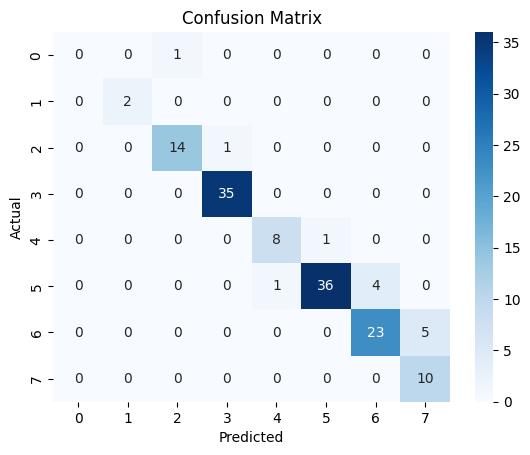

In [10]:

from sklearn.metrics import classification_report, confusion_matrix

y_pred = model.predict(X_test_lstm)
y_pred_labels = np.argmax(y_pred, axis=1)

print("Classification Report:")
print(classification_report(y_test, y_pred_labels))

conf_matrix = confusion_matrix(y_test, y_pred_labels)
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


## Hyperparameter Set 2 (Before Improvement)

This is a second baseline run using a higher epoch count and a larger batch size (100 epochs, batch size 64), with the same architecture as Hyperparameter Set 1 above. It is kept as an additional "before" reference to further illustrate the overfitting behavior, prior to applying any regularization or EarlyStopping.

In [11]:
import tensorflow as tf

np.random.seed(42)
tf.random.set_seed(42)

model_set2 = Sequential()
model_set2.add(LSTM(64, input_shape=(X_train_lstm.shape[1], X_train_lstm.shape[2]), return_sequences=False))
model_set2.add(Dropout(0.2))
model_set2.add(Dense(32, activation='relu'))
model_set2.add(Dense(len(np.unique(y)), activation='softmax'))

model_set2.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

history_set2 = model_set2.fit(X_train_lstm, y_train, epochs=100, batch_size=64, validation_data=(X_test_lstm, y_test))

Epoch 1/100
9/9 [==============================] - 4s 87ms/step - loss: 2.0303 - accuracy: 0.1950 - val_loss: 1.9788 - val_accuracy: 0.3333
Epoch 2/100
9/9 [==============================] - 0s 9ms/step - loss: 1.9208 - accuracy: 0.4521 - val_loss: 1.8812 - val_accuracy: 0.5106
Epoch 3/100
9/9 [==============================] - 0s 7ms/step - loss: 1.8153 - accuracy: 0.5408 - val_loss: 1.7767 - val_accuracy: 0.6241
Epoch 4/100
9/9 [==============================] - 0s 8ms/step - loss: 1.6956 - accuracy: 0.6454 - val_loss: 1.6566 - val_accuracy: 0.6950
Epoch 5/100
9/9 [==============================] - 0s 9ms/step - loss: 1.5580 - accuracy: 0.6809 - val_loss: 1.5207 - val_accuracy: 0.7234
Epoch 6/100
9/9 [==============================] - 0s 8ms/step - loss: 1.4200 - accuracy: 0.7163 - val_loss: 1.3741 - val_accuracy: 0.7518
Epoch 7/100
9/9 [==============================] - 0s 10ms/step - loss: 1.2674 - accuracy: 0.7553 - val_loss: 1.2264 - val_accuracy: 0.7660
Epoch 8/100
9/9 [========

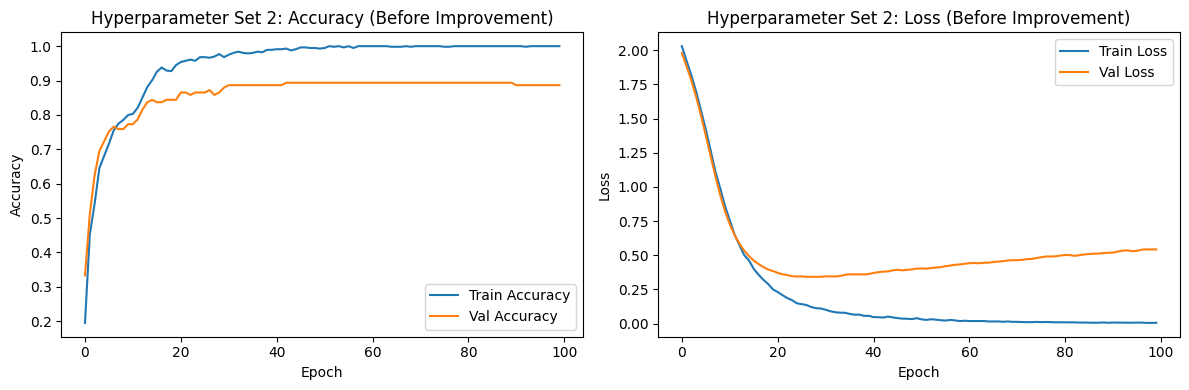

In [12]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history_set2.history['accuracy'], label='Train Accuracy')
plt.plot(history_set2.history['val_accuracy'], label='Val Accuracy')
plt.title("Hyperparameter Set 2: Accuracy (Before Improvement)")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history_set2.history['loss'], label='Train Loss')
plt.plot(history_set2.history['val_loss'], label='Val Loss')
plt.title("Hyperparameter Set 2: Loss (Before Improvement)")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.tight_layout()
plt.show()

## Addressing Overfitting

### What Overfitting Is and How It Was Identified

Overfitting happens when a model learns the training data too closely, including its noise, instead of learning patterns that generalize to unseen data. As a result, training performance keeps improving while validation performance stalls or gets worse.

This pattern is visible in both hyperparameter sets above. In Hyperparameter Set 1 (30 epochs, batch size 32), training accuracy climbs to around 99% while validation accuracy stays around 90% to 91%, a persistent gap that does not close as training continues. In Hyperparameter Set 2 (100 epochs, batch size 64), the effect is more severe: training accuracy reaches 100% after roughly 40 to 50 epochs, and instead of also improving, validation loss starts increasing after about epoch 20 to 30, even though validation accuracy stays flat near 90%. A rising validation loss alongside flat validation accuracy and near perfect training accuracy is a clear indicator of the model memorizing the training set rather than generalizing to unseen data.

### Steps Taken to Reduce Overfitting

Two changes were applied together to the LSTM model.

1. An EarlyStopping callback was added, monitoring val_loss with patience set to 10 epochs and restore_best_weights enabled. This stops training once validation loss stops improving for 10 consecutive epochs, and restores the model weights from the epoch with the lowest validation loss, so the final saved model is not the most overfit one.
2. Additional regularization was added inside the network. The Dropout rate after the LSTM layer was raised from 0.2 to 0.3, L2 regularization was added to the Dense(32) layer, and a second Dropout(0.3) layer was inserted after Dense(32) and before the output layer. Together these reduce the model's capacity to memorize the training set while still allowing it to learn useful patterns.

In [13]:
import tensorflow as tf
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.regularizers import l2

np.random.seed(42)
tf.random.set_seed(42)

model_improved = Sequential()
model_improved.add(LSTM(64, input_shape=(X_train_lstm.shape[1], X_train_lstm.shape[2]), return_sequences=False))
model_improved.add(Dropout(0.3))
model_improved.add(Dense(32, activation='relu', kernel_regularizer=l2(0.001)))
model_improved.add(Dropout(0.3))
model_improved.add(Dense(len(np.unique(y)), activation='softmax'))

model_improved.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

history_improved = model_improved.fit(
    X_train_lstm, y_train,
    epochs=100,
    batch_size=32,
    validation_data=(X_test_lstm, y_test),
    callbacks=[early_stop]
)

Epoch 1/100
18/18 [==============================] - 4s 49ms/step - loss: 2.1082 - accuracy: 0.1667 - val_loss: 2.0362 - val_accuracy: 0.3688
Epoch 2/100
18/18 [==============================] - 0s 6ms/step - loss: 1.9501 - accuracy: 0.4450 - val_loss: 1.9002 - val_accuracy: 0.6596
Epoch 3/100
18/18 [==============================] - 0s 5ms/step - loss: 1.7964 - accuracy: 0.5691 - val_loss: 1.7241 - val_accuracy: 0.7021
Epoch 4/100
18/18 [==============================] - 0s 6ms/step - loss: 1.5907 - accuracy: 0.6330 - val_loss: 1.5025 - val_accuracy: 0.7447
Epoch 5/100
18/18 [==============================] - 0s 6ms/step - loss: 1.3721 - accuracy: 0.7092 - val_loss: 1.2671 - val_accuracy: 0.8156
Epoch 6/100
18/18 [==============================] - 0s 6ms/step - loss: 1.1833 - accuracy: 0.7411 - val_loss: 1.0526 - val_accuracy: 0.8369
Epoch 7/100
18/18 [==============================] - 0s 6ms/step - loss: 0.9783 - accuracy: 0.7660 - val_loss: 0.8845 - val_accuracy: 0.8298
Epoch 8/100


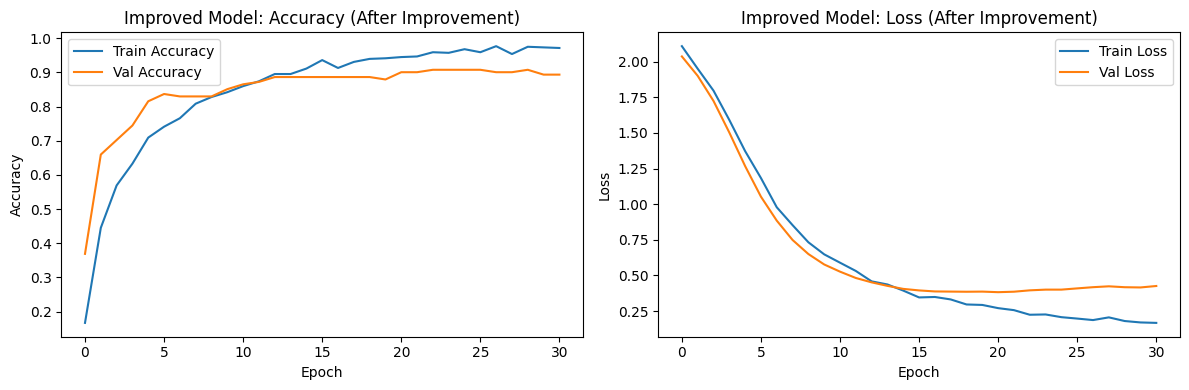

In [14]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history_improved.history['accuracy'], label='Train Accuracy')
plt.plot(history_improved.history['val_accuracy'], label='Val Accuracy')
plt.title("Improved Model: Accuracy (After Improvement)")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history_improved.history['loss'], label='Train Loss')
plt.plot(history_improved.history['val_loss'], label='Val Loss')
plt.title("Improved Model: Loss (After Improvement)")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.tight_layout()
plt.show()

In [15]:
loss_improved, accuracy_improved = model_improved.evaluate(X_test_lstm, y_test)
print(f"Improved Model Test Accuracy: {accuracy_improved:.4f}")
print(f"Improved Model Test Loss: {loss_improved:.4f}")

5/5 [==============================] - 0s 4ms/step - loss: 0.3826 - accuracy: 0.9007
Improved Model Test Accuracy: 0.9007
Improved Model Test Loss: 0.3826


5/5 [==============================] - 0s 1ms/step
Classification Report (Improved Model):
              precision    recall  f1-score   support

           0       0.00      0.00      0.00         1
           1       1.00      1.00      1.00         2
           2       0.93      0.93      0.93        15
           3       0.97      1.00      0.99        35
           4       1.00      0.89      0.94         9
           5       0.97      0.88      0.92        41
           6       0.79      0.82      0.81        28
           7       0.64      0.90      0.75        10

    accuracy                           0.90       141
   macro avg       0.79      0.80      0.79       141
weighted avg       0.90      0.90      0.90       141



C:\Users\Asus\anaconda3\envs\MS\lib\site-packages\sklearn\metrics\_classification.py:1318: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
C:\Users\Asus\anaconda3\envs\MS\lib\site-packages\sklearn\metrics\_classification.py:1318: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
C:\Users\Asus\anaconda3\envs\MS\lib\site-packages\sklearn\metrics\_classification.py:1318: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


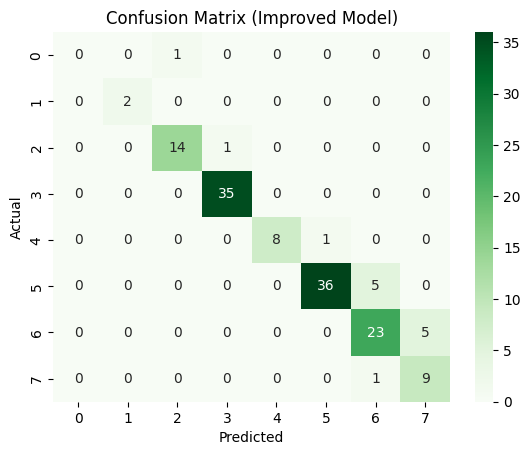

In [16]:
y_pred_improved = model_improved.predict(X_test_lstm)
y_pred_improved_labels = np.argmax(y_pred_improved, axis=1)

print("Classification Report (Improved Model):")
print(classification_report(y_test, y_pred_improved_labels))

conf_matrix_improved = confusion_matrix(y_test, y_pred_improved_labels)
sns.heatmap(conf_matrix_improved, annot=True, fmt='d', cmap='Greens')
plt.title("Confusion Matrix (Improved Model)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

## Comparison: Before vs After

| Model | Training Setup | Train Accuracy | Validation (Test) Accuracy | Train to Validation Gap | Validation Loss Behavior |
|---|---|---|---|---|---|
| Set 1 (before) | 30 epochs, batch size 32, fixed | 99.29% | 90.78% | 8.51 points | Drops to about 0.31 by epoch 15, then climbs back up to 0.40 by epoch 30 |
| Set 2 (before) | 100 epochs, batch size 64, fixed | 100.00% | 88.65% | 11.35 points | Drops to about 0.34 by epoch 29, then climbs sharply to 0.54 by epoch 100 |
| Improved (after) | Up to 100 epochs allowed, EarlyStopping halted training at epoch 31 and restored weights from epoch 21 (best validation loss), batch size 32 | 94.50% | 90.07% | 4.43 points | Reaches a minimum of about 0.38 at epoch 21, training stops before it can rise further |

The improved model reaches a test accuracy of 90.07%, close to Set 1's 90.78% (a difference of about 0.7 percentage points, well within the normal variation expected on a test set of only 141 samples). At the same time, the gap between training and validation accuracy is reduced from 8.51 percentage points in Set 1 to 4.43 percentage points in the improved model, and from 11.35 percentage points in Set 2 to 4.43 percentage points, showing a clear reduction in overfitting.

The main benefit of EarlyStopping is that it removes the need to guess a fixed epoch count in advance. Training now stops automatically once validation loss has not improved for 10 consecutive epochs, and the best performing weights (from epoch 21) are restored instead of keeping the weights from the final epoch. This is what prevents the unchecked validation loss increase seen in Set 2, where validation loss kept rising all the way through epoch 100.